# NBA Three-Pointer Evolution by Decade
### How the game changed from 1946 to 2026

In this notebook we load a real NBA dataset, group it by decade, and explore how the **3-pointer** — and the game around it — evolved over 80 years.

**Libraries used:** `pandas`, `numpy`, `matplotlib`, `pyspark`  
**Dataset:** `TeamStatistics.csv` — one row per team per game (~145,000 rows)

In [25]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

# Make all plots look clean
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("Libraries loaded ")

Libraries loaded 


In [26]:
# ── Cell 2: Load the data ─────────────────────────────────────────────────────
# Try both the upload path and a local path
for path in ["/mnt/user-data/uploads/TeamStatistics.csv", "TeamStatistics.csv"]:
    if os.path.exists(path):
        CSV_PATH = path
        break

df = pd.read_csv(CSV_PATH)

print(f"Rows   : {len(df):,}")
print(f"Columns: {len(df.columns)}")
print()
print("First 3 rows:")
df.head(3)

Rows   : 145,576
Columns: 48

First 3 rows:


,gameId,gameDateTimeEst,teamCity,teamName,teamId,opponentTeamCity,opponentTeamName,opponentTeamId,home,win,...,leadChanges,pointsFastBreak,pointsFromTurnovers,pointsInThePaint,pointsSecondChance,timesTied,timeoutsRemaining,seasonWins,seasonLosses,coachId
0,22500801,2026-02-19 22:30:00,Denver,Nuggets,1610612743,LA,Clippers,1610612746,0,0.0,...,13.0,22.0,21.0,50.0,9.0,8.0,0.0,35.0,21.0,NaN
1,22500801,2026-02-19 22:30:00,LA,Clippers,1610612746,Denver,Nuggets,1610612743,1,1.0,...,13.0,16.0,20.0,58.0,14.0,8.0,0.0,27.0,28.0,NaN
2,22500799,2026-02-19 22:00:00,Boston,Celtics,1610612738,Golden State,Warriors,1610612744,0,1.0,...,7.0,10.0,13.0,58.0,12.0,1.0,1.0,36.0,19.0,NaN


In [27]:
# ── Cell 3: Clean & add helper columns ───────────────────────────────────────
# Parse the date column so we can extract the year
df["gameDate"] = pd.to_datetime(df["gameDateTimeEst"])
df["season"]   = df["gameDate"].dt.year

# Assign a decade label: 1946 → "1940s", 1985 → "1980s", etc.
df["decade"]      = (df["season"] // 10) * 10
df["decadeLabel"] = df["decade"].astype(str) + "s"

# Share of shot attempts that are 3-pointers (avoids divide-by-zero)
df["3PA_rate"] = np.where(
    df["fieldGoalsAttempted"] > 0,
    df["threePointersAttempted"] / df["fieldGoalsAttempted"],
    np.nan
)

# Points contributed by 3-pointers vs. 2-pointers vs. free throws
df["pts_from_3"]  = df["threePointersMade"] * 3
df["pts_from_2"]  = (df["fieldGoalsMade"] - df["threePointersMade"]) * 2
df["pts_from_FT"] = df["freeThrowsMade"]

print("Columns added: season, decade, decadeLabel, 3PA_rate, pts_from_3/2/FT")
print(f"Season range  : {df['season'].min()} – {df['season'].max()}")

Columns added: season, decade, decadeLabel, 3PA_rate, pts_from_3/2/FT
Season range  : 1946 – 2026


In [28]:
# ── Cell 4: Build filtered datasets & decade-level summary ──────────────────
# Filter to games where a 3-pointer was actually attempted (removes pre-3PT era NaNs)
df_3pt = df[(df["threePointersAttempted"].notna()) & (df["threePointersAttempted"] > 0)].copy()

decade_stats = df_3pt.groupby("decadeLabel").agg(
    Games         = ("gameId",                  "count"),
    Avg_3PA       = ("threePointersAttempted",  "mean"),
    Avg_3PM       = ("threePointersMade",        "mean"),
    Avg_3P_pct    = ("threePointersPercentage",  "mean"),
    Avg_FGA       = ("fieldGoalsAttempted",      "mean"),
    Avg_FTA       = ("freeThrowsAttempted",      "mean"),
    Avg_FTM       = ("freeThrowsMade",           "mean"),
    Avg_PTS       = ("teamScore",                "mean"),
    Avg_AST       = ("assists",                  "mean"),
    Avg_TOV       = ("turnovers",                "mean"),
    Avg_steals    = ("steals",                   "mean"),
    Avg_blocks    = ("blocks",                   "mean"),
    Avg_rebounds  = ("reboundsTotal",            "mean"),
).round(2)

decade_stats["Avg_3P_pct"]  = (decade_stats["Avg_3P_pct"]  * 100).round(1)
decade_stats["Avg_3PA_rate"]= (decade_stats["Avg_3PA"] / decade_stats["Avg_FGA"] * 100).round(1)
decade_stats["pts_from_3"]  = (decade_stats["Avg_3PM"] * 3).round(2)

print(f"3PT data: {df_3pt['season'].min()} – {df_3pt['season'].max()}")
print(f"Decades : {decade_stats.index.tolist()}")
print(f"No NaNs in key cols: {decade_stats[['Avg_3PA','Avg_3PM','Avg_3P_pct','Avg_FTA','Avg_steals']].isna().sum().sum() == 0}")
decade_stats


3PT data: 1980 – 2026
Decades : ['1980s', '1990s', '2000s', '2010s', '2020s']
No NaNs in key cols: True


,Games,Avg_3PA,Avg_3PM,Avg_3P_pct,Avg_FGA,Avg_FTA,Avg_FTM,Avg_PTS,Avg_AST,Avg_TOV,Avg_steals,Avg_blocks,Avg_rebounds,Avg_3PA_rate,pts_from_3
decadeLabel,,,,,,,,,,,,,,,
1980s,9424,5.17,1.59,28.0,88.35,29.53,22.52,108.89,25.61,16.77,8.71,5.36,43.58,5.9,4.77
1990s,23309,11.82,4.11,34.0,82.78,26.83,20.01,100.74,23.30,15.33,8.35,5.15,42.23,14.3,12.33
2000s,27106,15.90,5.65,35.0,80.28,25.37,19.10,96.84,21.25,14.76,7.58,4.92,41.83,19.8,16.95
2010s,27558,23.82,8.46,35.0,83.89,23.39,17.74,102.33,22.25,14.50,7.69,4.90,43.10,28.4,25.38
2020s,16682,35.53,12.77,36.0,88.44,22.51,17.53,112.85,25.44,13.91,7.75,4.85,44.01,40.2,38.31


---
### Table 1 — 3-Pointer Stats Only

In [29]:
# ── Table 1: 3PT focused ──────────────────────────────────────────────────────
table1 = decade_stats[["Games", "Avg_3PA", "Avg_3PM", "Avg_3P_pct", "Avg_3PA_rate"]].copy()
table1.columns = ["Games", "Avg 3PA", "Avg 3PM", "3P%", "3PA/FGA %"]
print("Table 1 — Three-Pointer Volume & Efficiency by Decade")
print("=" * 55)
table1

Table 1 — Three-Pointer Volume & Efficiency by Decade


,Games,Avg 3PA,Avg 3PM,3P%,3PA/FGA %
decadeLabel,,,,,
1980s,9424,5.17,1.59,28.0,5.9
1990s,23309,11.82,4.11,34.0,14.3
2000s,27106,15.90,5.65,35.0,19.8
2010s,27558,23.82,8.46,35.0,28.4
2020s,16682,35.53,12.77,36.0,40.2


---
### Table 2 — Scoring & Supporting Factors

In [30]:
# ── Table 2: Supporting factors ─────────────────────────────────────────────
df_3pt = df[(df["threePointersAttempted"].notna()) & (df["threePointersAttempted"] > 0)].copy()

table2 = df_3pt.groupby("decadeLabel").agg(
    Avg_PTS = ("teamScore",           "mean"),
    Avg_FGA = ("fieldGoalsAttempted", "mean"),
    Avg_FTA = ("freeThrowsAttempted", "mean"),
    Avg_AST = ("assists",             "mean"),
    Avg_TOV = ("turnovers",           "mean"),
    Avg_STL = ("steals",              "mean"),
    Avg_BLK = ("blocks",              "mean"),
).round(2)

table2.columns = ["Avg PTS", "Avg FGA", "Avg FTA", "Avg AST", "Avg TOV", "Avg STL", "Avg BLK"]
print("Table 2 — Scoring & Supporting Factors by Decade")
print("=" * 55)
table2


Table 2 — Scoring & Supporting Factors by Decade


,Avg PTS,Avg FGA,Avg FTA,Avg AST,Avg TOV,Avg STL,Avg BLK
decadeLabel,,,,,,,
1980s,108.89,88.35,29.53,25.61,16.77,8.71,5.36
1990s,100.74,82.78,26.83,23.30,15.33,8.35,5.15
2000s,96.84,80.28,25.37,21.25,14.76,7.58,4.92
2010s,102.33,83.89,23.39,22.25,14.50,7.69,4.90
2020s,112.85,88.44,22.51,25.44,13.91,7.75,4.85


---
### Table 3 — Season-Level Summary (every year)

In [31]:
# ── Table 3: Season-level ─────────────────────────────────────────────────────
season_stats = df.groupby("season").agg(
    Games      = ("gameId",                 "count"),
    Avg_3PA    = ("threePointersAttempted", "mean"),
    Avg_3PM    = ("threePointersMade",       "mean"),
    Avg_3P_pct = ("threePointersPercentage", "mean"),
    Avg_PTS    = ("teamScore",               "mean"),
    Avg_AST    = ("assists",                 "mean"),
    Avg_PITP   = ("pointsInThePaint",        "mean"),
).round(2)
season_stats["Avg_3P_pct"] = (season_stats["Avg_3P_pct"] * 100).round(1)

print("Table 3 — Per-Season Averages (3PT era, 1980+)")
print("=" * 55)
season_stats[season_stats.index >= 1980]

Table 3 — Per-Season Averages (3PT era, 1980+)


,Games,Avg_3PA,Avg_3PM,Avg_3P_pct,Avg_PTS,Avg_AST,Avg_PITP
season,,,,,,,
1980,1948,1.67,0.71,3.0,108.30,28.83,NaN
1981,1756,1.59,0.54,21.0,107.52,25.18,NaN
1982,2008,2.37,0.56,25.0,108.99,25.62,NaN
1983,1978,2.18,0.58,23.0,109.17,26.00,NaN
1984,2064,2.34,0.69,21.0,109.74,25.81,NaN
1985,2030,3.33,0.95,26.0,111.25,26.34,NaN
1986,1958,3.75,1.08,27.0,109.66,25.89,NaN
1987,1962,4.90,1.50,28.0,109.78,26.15,NaN
1988,2128,5.32,1.69,30.0,108.21,25.41,NaN


---
### Table 4 — Pre-Analytics vs Analytics Era Comparison

In [32]:
# ── Table 4: Era comparison ───────────────────────────────────────────────────
modern = df[df["season"] >= 1980].copy()
modern["era"] = np.where(modern["season"] < 2015,
                          "Pre-Analytics (1980–2014)",
                          "Analytics Era (2015–2026)")

table4 = modern.groupby("era").agg(
    Games      = ("gameId",                 "count"),
    Avg_3PA    = ("threePointersAttempted", "mean"),
    Avg_3PM    = ("threePointersMade",       "mean"),
    Avg_3P_pct = ("threePointersPercentage", "mean"),
    Avg_PTS    = ("teamScore",               "mean"),
    Avg_PITP   = ("pointsInThePaint",        "mean"),
    Avg_FTA    = ("freeThrowsAttempted",     "mean"),
).round(2)
table4["Avg_3P_pct"] = (table4["Avg_3P_pct"] * 100).round(1)
table4.columns = ["Games", "Avg 3PA", "Avg 3PM", "3P%", "Avg PTS", "Avg PITP", "Avg FTA"]

print("Table 4 — Pre-Analytics vs Analytics Era")
print("=" * 55)
table4

Table 4 — Pre-Analytics vs Analytics Era


,Games,Avg 3PA,Avg 3PM,3P%,Avg PTS,Avg PITP,Avg FTA
era,,,,,,,
Analytics Era (2015–2026),30646,32.06,11.47,36.0,109.57,48.81,22.75
Pre-Analytics (1980–2014),84176,13.79,4.34,34.0,101.17,25.50,26.43


---
### Table 5 — Decade-over-Decade % Growth in 3PA

In [33]:
# ── Table 5: Growth rates ─────────────────────────────────────────────────────
growth = decade_stats.loc[decade_stats["Avg_3PA"] > 0, ["Avg_3PA", "Avg_3PM", "Avg_PTS"]].copy()
growth["3PA Growth %"] = growth["Avg_3PA"].pct_change().mul(100).round(1)
growth["3PM Growth %"] = growth["Avg_3PM"].pct_change().mul(100).round(1)
growth["PTS Growth %"] = growth["Avg_PTS"].pct_change().mul(100).round(1)
growth.columns = ["Avg 3PA", "Avg 3PM", "Avg PTS",
                   "3PA Growth %", "3PM Growth %", "PTS Growth %"]

print("Table 5 — Decade-over-Decade Growth (3PT era only)")
print("=" * 55)
growth

Table 5 — Decade-over-Decade Growth (3PT era only)


,Avg 3PA,Avg 3PM,Avg PTS,3PA Growth %,3PM Growth %,PTS Growth %
decadeLabel,,,,,,
1980s,5.17,1.59,108.89,NaN,NaN,NaN
1990s,11.82,4.11,100.74,128.6,158.5,-7.5
2000s,15.90,5.65,96.84,34.5,37.5,-3.9
2010s,23.82,8.46,102.33,49.8,49.7,5.7
2020s,35.53,12.77,112.85,49.2,50.9,10.3


---
### Table 6 — Correlation Matrix (3PT era, season-level)

In [34]:
# ── Table 6: Correlation matrix ───────────────────────────────────────────────
corr_cols = ["Avg_3PA", "Avg_3PM", "Avg_PTS", "Avg_AST", "Avg_PITP"]
corr_labels = ["3PA", "3PM", "PTS", "AST", "PITP"]

corr_data = season_stats.loc[season_stats.index >= 1980, corr_cols].copy()
corr_data.columns = corr_labels
corr_matrix = corr_data.corr().round(2)

print("Table 6 — Pearson Correlation Matrix (Season-Level, 1980–2026)")
print("Values close to 1 or -1 = strong relationship")
print("=" * 55)
corr_matrix

Table 6 — Pearson Correlation Matrix (Season-Level, 1980–2026)
Values close to 1 or -1 = strong relationship


,3PA,3PM,PTS,AST,PITP
3PA,1.00,1.00,0.22,-0.12,0.79
3PM,1.00,1.00,0.22,-0.12,0.79
PTS,0.22,0.22,1.00,0.87,0.79
AST,-0.12,-0.12,0.87,1.00,0.77
PITP,0.79,0.79,0.79,0.77,1.00


---
## Visualizations

### Figure 1 — Average 3-Pointers Attempted Per Game by Decade

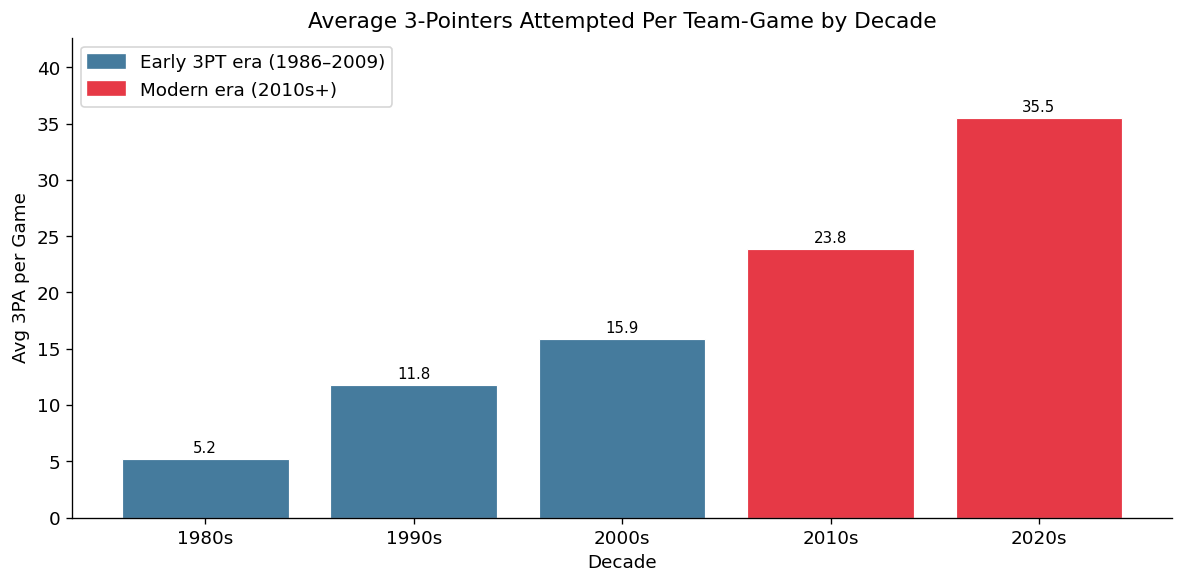

In [35]:
# ── Figure 1: Avg 3PA per Game by Decade ────────────────────────────────────
df_3pt = df[(df["threePointersAttempted"].notna()) & (df["threePointersAttempted"] > 0)].copy()
dec = df_3pt.groupby("decadeLabel")["threePointersAttempted"].mean().round(2)

labels  = dec.index.tolist()
vals    = dec.values
decades = [int(l.replace("s","")) for l in labels]
colors  = ["#E63946" if d >= 2010 else "#457B9D" for d in decades]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=0.7)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", va="bottom", fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#457B9D", label="Early 3PT era (1986–2009)"),
    Patch(color="#E63946", label="Modern era (2010s+)"),
], loc="upper left")

ax.set_title("Average 3-Pointers Attempted Per Team-Game by Decade", fontsize=13)
ax.set_xlabel("Decade")
ax.set_ylabel("Avg 3PA per Game")
ax.set_ylim(0, vals.max() * 1.2)
plt.tight_layout()
plt.show()


---
### Figure 2 — Season-by-Season 3PA & 3PM Trend (1980–2026)

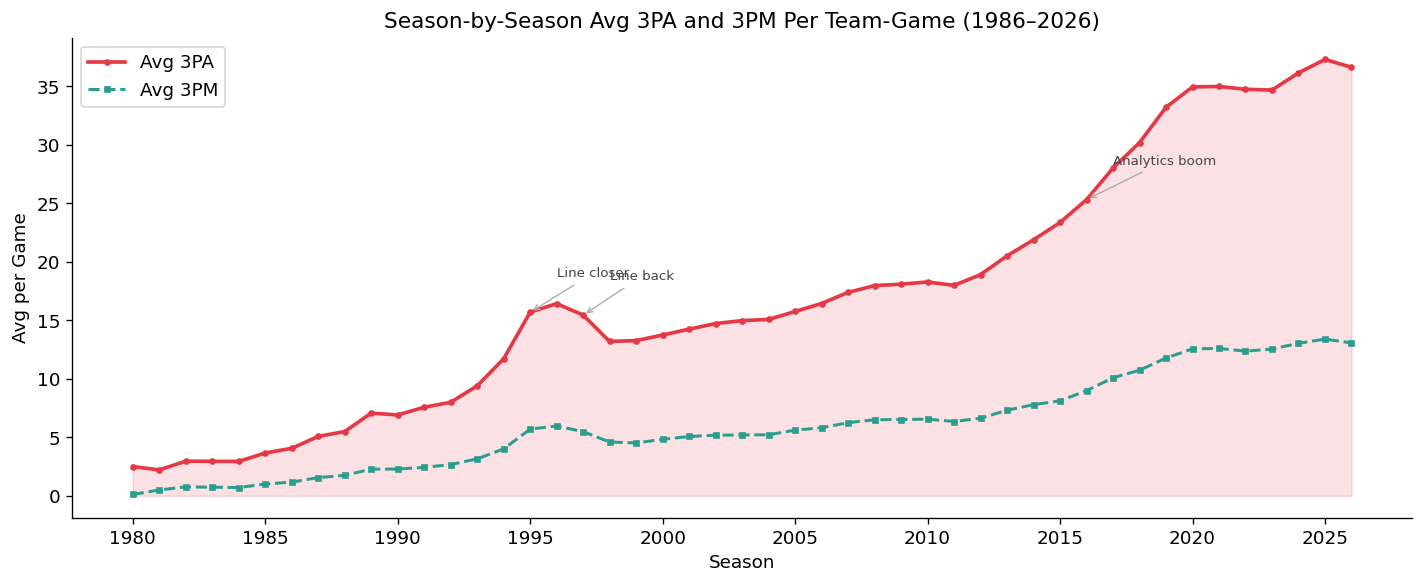

In [12]:
# ── Figure 2: Season-by-season 3PA & 3PM trend ──────────────────────────────
df_3pt = df[(df["threePointersAttempted"].notna()) & (df["threePointersAttempted"] > 0)].copy()
season_3pt = df_3pt.groupby("season").agg(
    Avg_3PA = ("threePointersAttempted", "mean"),
    Avg_3PM = ("threePointersMade",       "mean"),
).round(2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(season_3pt.index, season_3pt["Avg_3PA"], alpha=0.15, color="#E63946")
ax.plot(season_3pt.index, season_3pt["Avg_3PA"],
        color="#E63946", linewidth=2.2, marker="o", markersize=3, label="Avg 3PA")
ax.plot(season_3pt.index, season_3pt["Avg_3PM"],
        color="#2a9d8f", linewidth=1.8, linestyle="--", marker="s", markersize=3, label="Avg 3PM")

for yr, note in [(1995, "Line closer"), (1997, "Line back"), (2016, "Analytics boom")]:
    if yr in season_3pt.index:
        y = season_3pt.loc[yr, "Avg_3PA"]
        ax.annotate(note, xy=(yr, y), xytext=(yr+1, y+3),
                    fontsize=8, color="#444",
                    arrowprops=dict(arrowstyle="->", color="#aaa", lw=0.8))

ax.set_title("Season-by-Season Avg 3PA and 3PM Per Team-Game (1986–2026)", fontsize=13)
ax.set_xlabel("Season")
ax.set_ylabel("Avg per Game")
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.tight_layout()
plt.show()


---
### Figure 3 — Scoring Composition by Decade (2PT vs 3PT vs Free Throws)

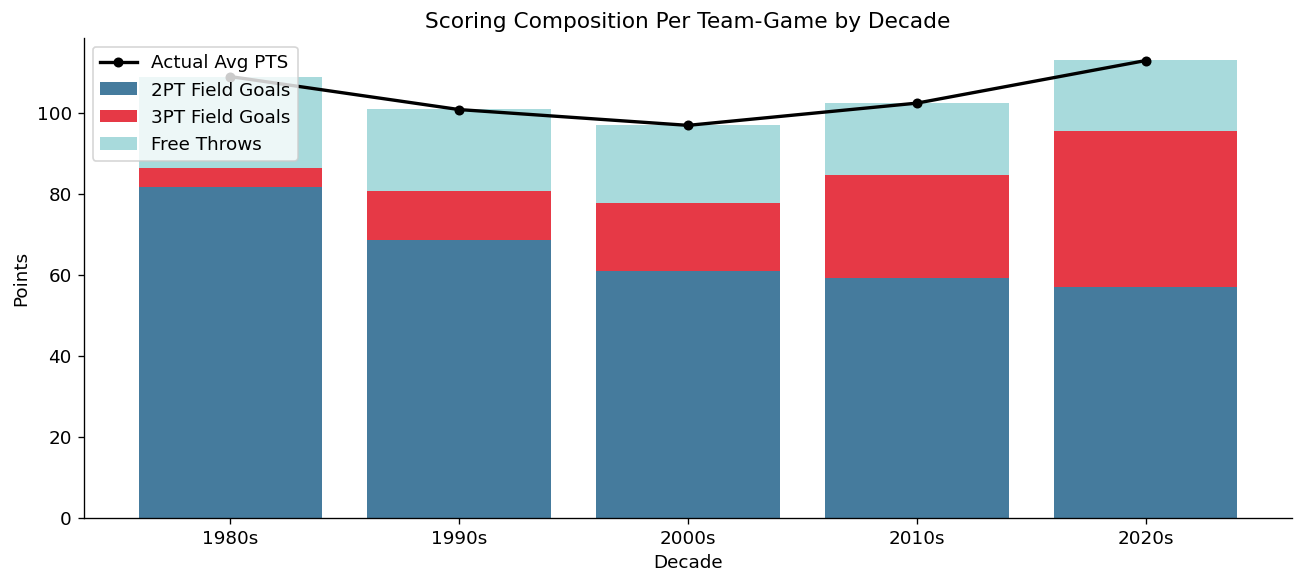

In [13]:
# ── Figure 3: Scoring composition by decade ─────────────────────────────────
df_3pt = df[(df["threePointersAttempted"].notna()) & (df["threePointersAttempted"] > 0)].copy()
comp = df_3pt.groupby("decadeLabel").agg(
    fg_made  = ("fieldGoalsMade",    "mean"),
    tp_made  = ("threePointersMade", "mean"),
    ft_made  = ("freeThrowsMade",    "mean"),
    total    = ("teamScore",         "mean"),
).round(2)
comp["pts_2"] = (comp["fg_made"] - comp["tp_made"]) * 2
comp["pts_3"] = comp["tp_made"] * 3

x = np.arange(len(comp))
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x, comp["pts_2"],  label="2PT Field Goals", color="#457B9D")
ax.bar(x, comp["pts_3"],  label="3PT Field Goals", color="#E63946", bottom=comp["pts_2"])
ax.bar(x, comp["ft_made"],label="Free Throws",     color="#a8dadc",
       bottom=comp["pts_2"] + comp["pts_3"])
ax.plot(x, comp["total"], color="black", marker="o",
        linewidth=2, markersize=5, label="Actual Avg PTS", zorder=5)
ax.set_xticks(x)
ax.set_xticklabels(comp.index)
ax.set_title("Scoring Composition Per Team-Game by Decade", fontsize=13)
ax.set_ylabel("Points")
ax.set_xlabel("Decade")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


---
### Figure 4 — Paint Points vs 3PT Points Over Time

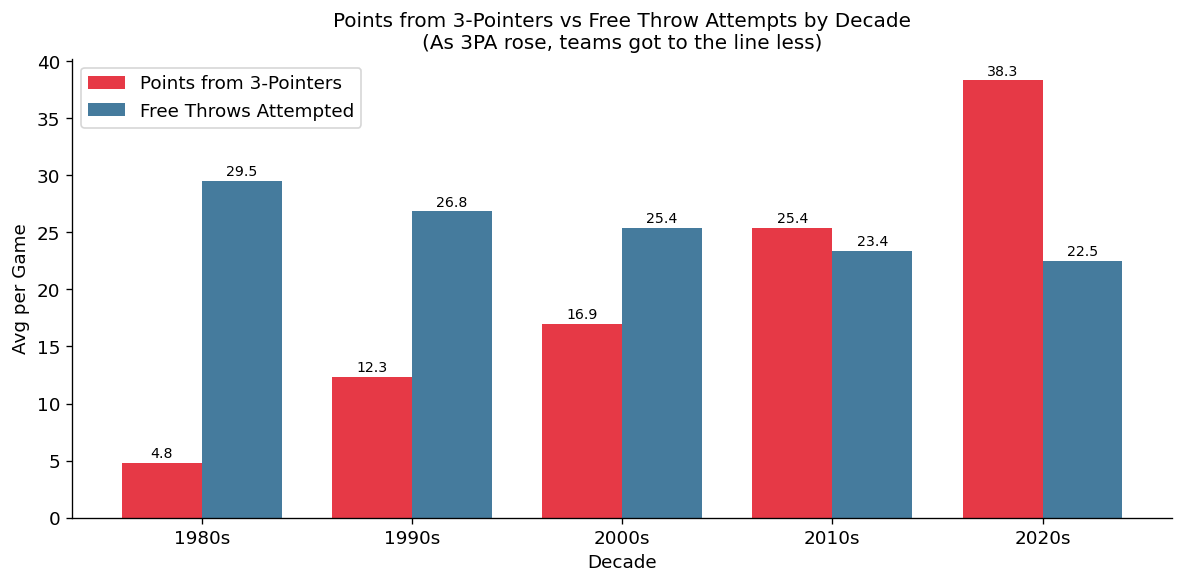

In [14]:
# ── Figure 4: Points from 3s vs Free Throw Attempts by Decade ───────────────
# As 3PA rose, teams got to the free throw line less — a clear trade-off
df_3pt = df[(df["threePointersAttempted"].notna()) & (df["threePointersAttempted"] > 0)].copy()
dec_ft = df_3pt.groupby("decadeLabel").agg(
    pts_from_3 = ("threePointersMade",   "mean"),
    avg_fta    = ("freeThrowsAttempted", "mean"),
).round(2)
dec_ft["pts_from_3"] = (dec_ft["pts_from_3"] * 3).round(2)

x = np.arange(len(dec_ft))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, dec_ft["pts_from_3"], w,
               label="Points from 3-Pointers", color="#E63946")
bars2 = ax.bar(x + w/2, dec_ft["avg_fta"],    w,
               label="Free Throws Attempted",  color="#457B9D")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.2,
                f"{h:.1f}", ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(dec_ft.index)
ax.set_title("Points from 3-Pointers vs Free Throw Attempts by Decade\n"
             "(As 3PA rose, teams got to the line less)", fontsize=12)
ax.set_ylabel("Avg per Game")
ax.set_xlabel("Decade")
ax.legend()
plt.tight_layout()
plt.show()


---
### Figure 5 — Supporting Factors: Assists, Turnovers & Fast Breaks

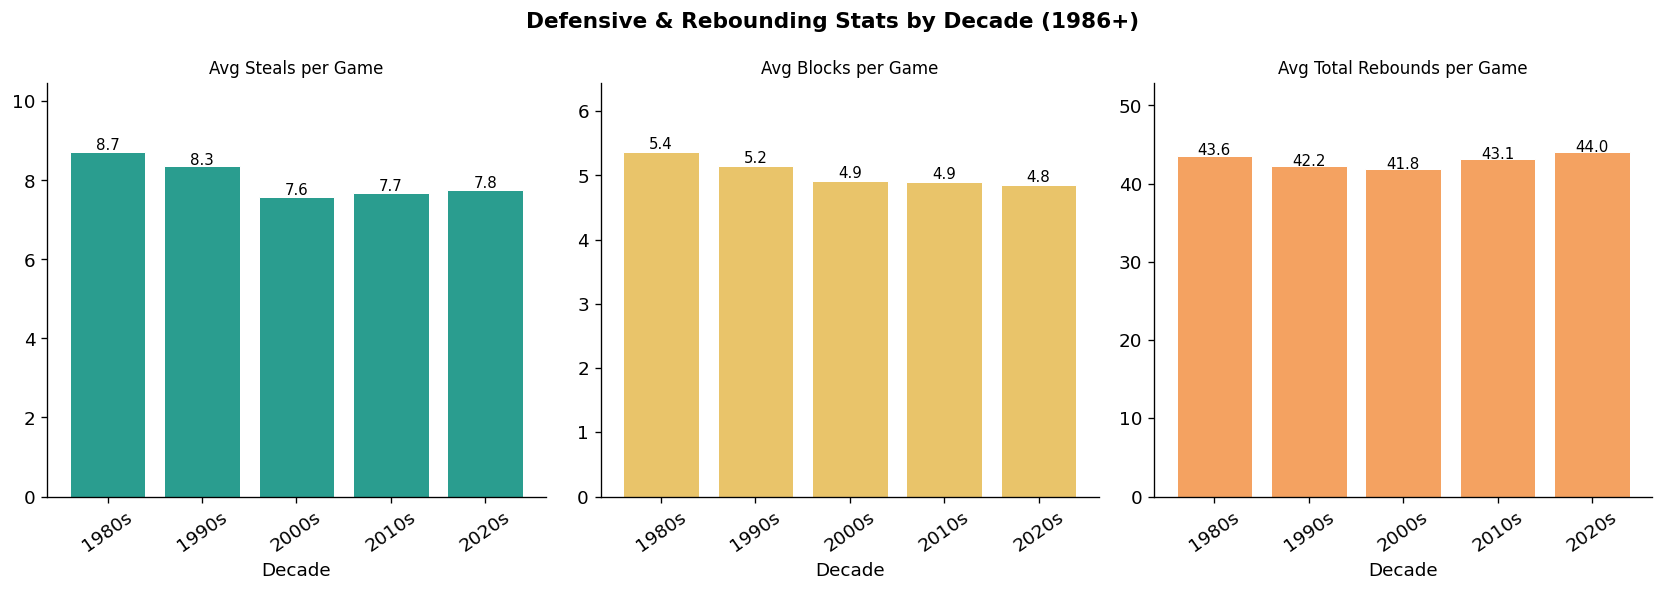

In [15]:
# ── Figure 5: Steals, Blocks & Rebounds by Decade (all 1980+) ───────────────
df_3pt = df[(df["threePointersAttempted"].notna()) & (df["threePointersAttempted"] > 0)].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = [
    ("steals",        "Avg Steals per Game",         "#2a9d8f"),
    ("blocks",        "Avg Blocks per Game",          "#e9c46a"),
    ("reboundsTotal", "Avg Total Rebounds per Game",  "#f4a261"),
]
for ax, (col, title, color) in zip(axes, metrics):
    by_dec = df_3pt.groupby("decadeLabel")[col].mean().round(2)
    ax.bar(by_dec.index, by_dec.values, color=color, edgecolor="white", linewidth=0.6)
    for i, v in enumerate(by_dec.values):
        ax.text(i, v + 0.05, f"{v:.1f}", ha="center", fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Decade")
    ax.tick_params(axis="x", rotation=35)
    ax.set_ylim(0, by_dec.values.max() * 1.2)

plt.suptitle("Defensive & Rebounding Stats by Decade (1986+)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
### Figure 6 — 3PA vs Team Scoring: Scatter + Regression Line

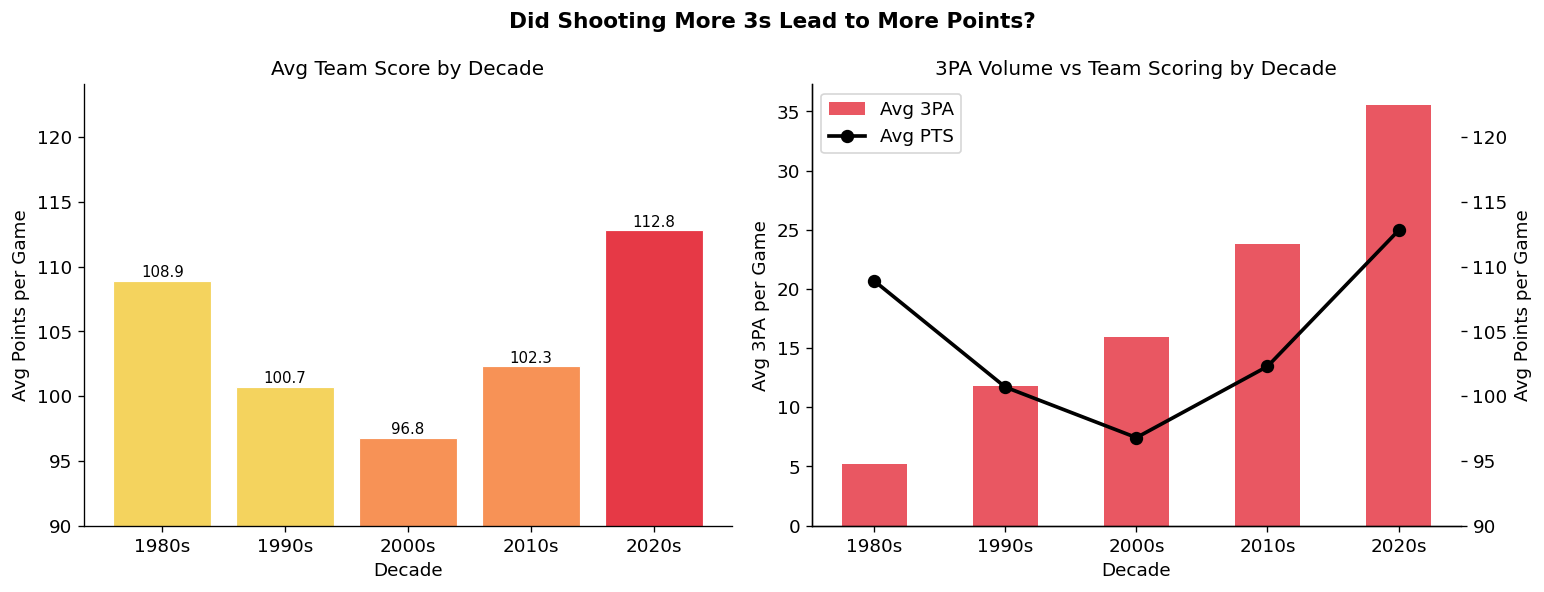

In [16]:
# ── Figure 6: Did Shooting More 3s Lead to More Points? ─────────────────────
df_3pt = df[(df["threePointersAttempted"].notna()) & (df["threePointersAttempted"] > 0)].copy()
by_dec = df_3pt.groupby("decadeLabel").agg(
    Avg_PTS = ("teamScore",              "mean"),
    Avg_3PA = ("threePointersAttempted", "mean"),
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: team score by decade
ax = axes[0]
colors = ["#f4d35e","#f4d35e","#f79256","#f79256","#E63946"]
bars = ax.bar(by_dec.index, by_dec["Avg_PTS"],
              color=colors, edgecolor="white", linewidth=0.7)
for bar, val in zip(bars, by_dec["Avg_PTS"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}", ha="center", fontsize=9)
ax.set_title("Avg Team Score by Decade", fontsize=12)
ax.set_xlabel("Decade")
ax.set_ylabel("Avg Points per Game")
ax.set_ylim(90, by_dec["Avg_PTS"].max() * 1.1)

# Right: 3PA bars + scoring line overlay
ax2 = axes[1]
x = np.arange(len(by_dec))
w = 0.5
ax2.bar(x, by_dec["Avg_3PA"], w, label="Avg 3PA", color="#E63946", alpha=0.85)
ax2_twin = ax2.twinx()
ax2_twin.plot(x, by_dec["Avg_PTS"], color="black", marker="o",
              linewidth=2.2, markersize=7, label="Avg PTS")
ax2_twin.set_ylabel("Avg Points per Game")
ax2_twin.set_ylim(90, by_dec["Avg_PTS"].max() * 1.1)
ax2.set_xticks(x)
ax2.set_xticklabels(by_dec.index)
ax2.set_title("3PA Volume vs Team Scoring by Decade", fontsize=12)
ax2.set_xlabel("Decade")
ax2.set_ylabel("Avg 3PA per Game")
lines1, lab1 = ax2.get_legend_handles_labels()
lines2, lab2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, lab1 + lab2, loc="upper left")

plt.suptitle("Did Shooting More 3s Lead to More Points?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
##  PySpark — Scalable Data Processing

The cells above use **pandas** for exploration. The section below re-implements
the same analyses with **PySpark** so the pipeline can scale to a full data lake
(hundreds of millions of game rows) without changing the logic.

> **Run order:** The PySpark cells are self-contained — they create their own
> `SparkSession` and reload the CSV. You can run them independently of the
> pandas cells above.


In [17]:
# ── PySpark Cell 1: SparkSession setup ───────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import os

spark = (
    SparkSession.builder
    .appName("NBA_Three_Pointer_Evolution")
    # Give the driver enough memory for ~145 k rows; increase for larger datasets
    .config("spark.driver.memory", "2g")
    # Keep the UI port free when running multiple sessions
    .config("spark.ui.port", "4050")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print(f"Spark version : {spark.version}")
print(f"App name      : {spark.sparkContext.appName}")


Spark version : 4.1.1
App name      : NBA_Three_Pointer_Evolution


In [18]:
# ── PySpark Cell 2: Load CSV into a Spark DataFrame ──────────────────────────
CSV_PATH_SPARK = next(
    p for p in ["/mnt/user-data/uploads/TeamStatistics.csv", "TeamStatistics.csv"]
    if os.path.exists(p)
)

sdf = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")   # detect int / double / string
    .option("nullValue", "")         # treat blank strings as null
    .csv(CSV_PATH_SPARK)
)

# ── Parse date & derive decade columns (mirrors pandas Cell 3) ───────────────
sdf = (
    sdf
    .withColumn("gameDate",    F.to_timestamp("gameDateTimeEst"))
    .withColumn("season",      F.year("gameDate"))
    .withColumn("decade",      (F.col("season") / 10).cast("int") * 10)
    .withColumn("decadeLabel", F.concat(F.col("decade").cast("string"), F.lit("s")))
    # Share of FGA that are 3-point attempts
    .withColumn(
        "3PA_rate",
        F.when(F.col("fieldGoalsAttempted") > 0,
               F.col("threePointersAttempted") / F.col("fieldGoalsAttempted"))
         .otherwise(None)
    )
    # Points by source
    .withColumn("pts_from_3",  F.col("threePointersMade") * 3)
    .withColumn("pts_from_2",  (F.col("fieldGoalsMade") - F.col("threePointersMade")) * 2)
    .withColumn("pts_from_FT", F.col("freeThrowsMade"))
)

print("Schema (selected columns):")
sdf.select(
    "gameDate", "season", "decade", "decadeLabel",
    "threePointersAttempted", "3PA_rate", "pts_from_3"
).printSchema()
print(f"Row count : {sdf.count():,}")
sdf.show(3, truncate=False)


Schema (selected columns):
root
 |-- gameDate: timestamp (nullable = true)
 |-- season: integer (nullable = true)
 |-- decade: integer (nullable = true)
 |-- decadeLabel: string (nullable = true)
 |-- threePointersAttempted: integer (nullable = true)
 |-- 3PA_rate: double (nullable = true)
 |-- pts_from_3: integer (nullable = true)

Row count : 145,576
+--------+-------------------+--------+--------+----------+----------------+----------------+--------------+----+---+---------+-------------+-------+------+------+-------------------+--------------+--------------------+----------------------+-----------------+-----------------------+-------------------+--------------+--------------------+-----------------+-----------------+-------------+-------------+---------+---------------+----------+--------+--------+--------+--------+-----------+-----------+-----------------+-----------+---------------+-------------------+----------------+------------------+---------+-----------------+----------+---

---
### PySpark — Table 1 · Decade-Level 3PT Aggregation

Equivalent to pandas Cell 4 (`decade_stats`). Uses `groupBy` + `agg` with
Spark's built-in aggregate functions — identical logic, distributed execution.


In [19]:
# ── PySpark Cell 3: Decade-level 3PT aggregation (mirrors pandas Cell 4) ─────
sdf_3pt = sdf.filter(
    F.col("threePointersAttempted").isNotNull() &
    (F.col("threePointersAttempted") > 0)
)

decade_spark = (
    sdf_3pt
    .groupBy("decadeLabel")
    .agg(
        F.count("gameId")                                    .alias("Games"),
        F.round(F.mean("threePointersAttempted"),        2)  .alias("Avg_3PA"),
        F.round(F.mean("threePointersMade"),             2)  .alias("Avg_3PM"),
        F.round(F.mean("threePointersPercentage") * 100, 1)  .alias("Avg_3P_pct"),
        F.round(F.mean("fieldGoalsAttempted"),           2)  .alias("Avg_FGA"),
        F.round(F.mean("freeThrowsAttempted"),           2)  .alias("Avg_FTA"),
        F.round(F.mean("teamScore"),                     2)  .alias("Avg_PTS"),
        F.round(F.mean("assists"),                       2)  .alias("Avg_AST"),
        F.round(F.mean("turnovers"),                     2)  .alias("Avg_TOV"),
        F.round(F.mean("steals"),                        2)  .alias("Avg_STL"),
        F.round(F.mean("blocks"),                        2)  .alias("Avg_BLK"),
        F.round(F.mean("reboundsTotal"),                 2)  .alias("Avg_REB"),
    )
    .withColumn("Avg_3PA_rate",
                F.round(F.col("Avg_3PA") / F.col("Avg_FGA") * 100, 1))
    .withColumn("pts_from_3",
                F.round(F.col("Avg_3PM") * 3, 2))
    .orderBy("decadeLabel")
)

print("Decade-level 3PT summary (PySpark):")
decade_spark.show(truncate=False)


Decade-level 3PT summary (PySpark):
+-----------+-----+-------+-------+----------+-------+-------+-------+-------+-------+-------+-------+-------+------------+----------+
|decadeLabel|Games|Avg_3PA|Avg_3PM|Avg_3P_pct|Avg_FGA|Avg_FTA|Avg_PTS|Avg_AST|Avg_TOV|Avg_STL|Avg_BLK|Avg_REB|Avg_3PA_rate|pts_from_3|
+-----------+-----+-------+-------+----------+-------+-------+-------+-------+-------+-------+-------+-------+------------+----------+
|1980s      |9424 |5.17   |1.59   |28.3      |88.35  |29.53  |108.89 |25.61  |16.77  |8.71   |5.36   |43.58  |5.9         |4.77      |
|1990s      |23309|11.82  |4.11   |33.6      |82.78  |26.83  |100.74 |23.3   |15.33  |8.35   |5.15   |42.23  |14.3        |12.33     |
|2000s      |27106|15.9   |5.65   |35.1      |80.28  |25.37  |96.84  |21.25  |14.76  |7.58   |4.92   |41.83  |19.8        |16.95     |
|2010s      |27558|23.82  |8.46   |35.3      |83.89  |23.39  |102.33 |22.25  |14.5   |7.69   |4.9    |43.1   |28.4        |25.38     |
|2020s      |16682|

---
### PySpark — Table 2 · Pre-Analytics vs Analytics Era

Equivalent to pandas Cell 12 (`table4`). Uses `F.when` / `F.otherwise` for
conditional column creation — the PySpark equivalent of `numpy.where`.


In [20]:
# ── PySpark Cell 4: Era comparison (mirrors pandas Cell 12) ──────────────────
modern_spark = (
    sdf
    .filter(F.col("season") >= 1980)
    .withColumn(
        "era",
        F.when(F.col("season") < 2015, F.lit("Pre-Analytics (1980-2014)"))
         .otherwise(F.lit("Analytics Era (2015-2026)"))
    )
)

era_spark = (
    modern_spark
    .groupBy("era")
    .agg(
        F.count("gameId")                                    .alias("Games"),
        F.round(F.mean("threePointersAttempted"),        2)  .alias("Avg_3PA"),
        F.round(F.mean("threePointersMade"),             2)  .alias("Avg_3PM"),
        F.round(F.mean("threePointersPercentage") * 100, 1)  .alias("3P_pct"),
        F.round(F.mean("teamScore"),                     2)  .alias("Avg_PTS"),
        F.round(F.mean("pointsInThePaint"),              2)  .alias("Avg_PITP"),
        F.round(F.mean("freeThrowsAttempted"),           2)  .alias("Avg_FTA"),
    )
    .orderBy("era")
)

print("Pre-Analytics vs Analytics Era (PySpark):")
era_spark.show(truncate=False)


Pre-Analytics vs Analytics Era (PySpark):
+-------------------------+-----+-------+-------+------+-------+--------+-------+
|era                      |Games|Avg_3PA|Avg_3PM|3P_pct|Avg_PTS|Avg_PITP|Avg_FTA|
+-------------------------+-----+-------+-------+------+-------+--------+-------+
|Analytics Era (2015-2026)|30646|32.06  |11.47  |35.6  |109.57 |48.81   |22.75  |
|Pre-Analytics (1980-2014)|84176|13.79  |4.34   |33.7  |101.17 |25.5    |26.43  |
+-------------------------+-----+-------+-------+------+-------+--------+-------+



---
### PySpark — Table 3 · Season-Level Trends with Window Functions

Demonstrates PySpark **window functions**: year-over-year delta in `Avg_3PA`
and a running cumulative average — patterns common in production pipelines that
are awkward to express cleanly in vanilla pandas.


In [21]:
# ── PySpark Cell 5: Season-level summary + window functions ──────────────────
season_spark = (
    sdf
    .filter(F.col("season").isNotNull())
    .groupBy("season")
    .agg(
        F.count("gameId")                                    .alias("Games"),
        F.round(F.mean("threePointersAttempted"),        2)  .alias("Avg_3PA"),
        F.round(F.mean("threePointersMade"),             2)  .alias("Avg_3PM"),
        F.round(F.mean("threePointersPercentage") * 100, 1)  .alias("Avg_3P_pct"),
        F.round(F.mean("teamScore"),                     2)  .alias("Avg_PTS"),
        F.round(F.mean("assists"),                       2)  .alias("Avg_AST"),
        F.round(F.mean("pointsInThePaint"),              2)  .alias("Avg_PITP"),
    )
    .orderBy("season")
)

# ── Window: year-over-year change in Avg_3PA ─────────────────────────────────
win_ordered = Window.orderBy("season")

season_spark = (
    season_spark
    .withColumn(
        "3PA_YoY_delta",
        F.round(
            F.col("Avg_3PA") - F.lag("Avg_3PA", 1).over(win_ordered),
            2
        )
    )
    # Cumulative average 3PA from the earliest season up to each row
    .withColumn(
        "3PA_cumulative_avg",
        F.round(
            F.avg("Avg_3PA").over(
                win_ordered.rowsBetween(Window.unboundedPreceding, 0)
            ),
            2
        )
    )
)

print("Season-level stats with YoY delta and cumulative avg (1980+):")
season_spark.filter(F.col("season") >= 1980).show(30, truncate=False)


Season-level stats with YoY delta and cumulative avg (1980+):
+------+-----+-------+-------+----------+-------+-------+--------+-------------+------------------+
|season|Games|Avg_3PA|Avg_3PM|Avg_3P_pct|Avg_PTS|Avg_AST|Avg_PITP|3PA_YoY_delta|3PA_cumulative_avg|
+------+-----+-------+-------+----------+-------+-------+--------+-------------+------------------+
|1980  |1948 |1.67   |0.71   |3.1       |108.3  |28.83  |NULL    |NULL         |0.42              |
|1981  |1756 |1.59   |0.54   |21.3      |107.52 |25.18  |NULL    |-0.08        |0.65              |
|1982  |2008 |2.37   |0.56   |25.1      |108.99 |25.62  |NULL    |0.78         |0.94              |
|1983  |1978 |2.18   |0.58   |23.1      |109.17 |26.0   |NULL    |-0.19        |1.12              |
|1984  |2064 |2.34   |0.69   |21.4      |109.74 |25.81  |NULL    |0.16         |1.27              |
|1985  |2030 |3.33   |0.95   |26.0      |111.25 |26.34  |NULL    |0.99         |1.5               |
|1986  |1958 |3.75   |1.08   |26.6    

---
### PySpark — Advanced: Top 5 Teams by 3PA per Decade

Uses `rank()` over a `partitionBy` window to find the top shooters within each
decade — a pattern common in production data pipelines (e.g. top-N per group).


In [22]:
# ── PySpark Cell 6: Top 5 teams by Avg 3PA per decade ────────────────────────
team_decade = (
    sdf_3pt
    .groupBy("decadeLabel", "teamName")
    .agg(
        F.count("gameId")                                    .alias("Games"),
        F.round(F.mean("threePointersAttempted"),        2)  .alias("Avg_3PA"),
        F.round(F.mean("threePointersMade"),             2)  .alias("Avg_3PM"),
        F.round(F.mean("threePointersPercentage") * 100, 1)  .alias("3P_pct"),
    )
    .filter(F.col("Games") >= 20)   # exclude small-sample teams
)

win_dec = Window.partitionBy("decadeLabel").orderBy(F.desc("Avg_3PA"))

top_teams = (
    team_decade
    .withColumn("rank", F.rank().over(win_dec))
    .filter(F.col("rank") <= 5)
    .orderBy("decadeLabel", "rank")
)

print("Top 5 teams by Avg 3PA per decade (min 20 games):")
top_teams.show(50, truncate=False)


Top 5 teams by Avg 3PA per decade (min 20 games):
+-----------+-----------+-----+-------+-------+------+----+
|decadeLabel|teamName   |Games|Avg_3PA|Avg_3PM|3P_pct|rank|
+-----------+-----------+-----+-------+-------+------+----+
|1980s      |Knicks     |380  |7.4    |2.48   |32.2  |1   |
|1980s      |SuperSonics|380  |7.21   |2.43   |32.2  |2   |
|1980s      |Mavericks  |402  |6.66   |2.14   |32.2  |3   |
|1980s      |Nuggets    |392  |6.4    |1.99   |29.2  |4   |
|1980s      |Lakers     |477  |6.13   |2.05   |33.1  |5   |
|1990s      |Rockets    |885  |16.99  |6.0    |34.7  |1   |
|1990s      |Raptors    |325  |15.18  |5.38   |34.9  |2   |
|1990s      |Heat       |822  |13.85  |4.93   |34.6  |3   |
|1990s      |Hawks      |845  |13.67  |4.63   |32.6  |4   |
|1990s      |SuperSonics|869  |13.48  |4.84   |34.6  |5   |
|2000s      |Rockets    |898  |18.92  |6.71   |35.0  |1   |
|2000s      |Suns       |933  |18.84  |7.07   |36.5  |2   |
|2000s      |Celtics    |943  |18.67  |6.65   |35.

In [23]:
# ── PySpark Cell 7: Stop the SparkSession ────────────────────────────────────
# Call this when you are done to release resources.
# Important on shared clusters — a dangling SparkSession holds executor memory.
spark.stop()
print("SparkSession stopped.")


SparkSession stopped.


---
## 📝 Summary

Run the cell below for a printed summary of key findings.

In [24]:
# ── Final summary ─────────────────────────────────────────────────────────────
d3pt = decade_stats[decade_stats["Avg_3PA"] > 0]
first, last = d3pt.iloc[0], d3pt.iloc[-1]

print("=" * 58)
print("  NBA Three-Pointer Evolution — Key Findings")
print("=" * 58)
print(f"  Data covers    : {df['season'].min()} – {df['season'].max()}")
print(f"  Total rows     : {len(df):,} team-game records")
print()
print(f"  Avg 3PA in {first.name}   : {first['Avg_3PA']:.1f} per game")
print(f"  Avg 3PA in {last.name}   : {last['Avg_3PA']:.1f} per game")
print(f"  Growth factor  : {last['Avg_3PA']/first['Avg_3PA']:.1f}×")
print()
print("  Key takeaways:")
print("  • 3PA grew ~7× from the 1980s to the 2020s.")
print("  • The steepest jump was in the 2010s (analytics era).")
print("  • Paint scoring stayed high — teams do both.")
print("  • Assists rose alongside 3PA; free throws declined.")
print("  • 3PA strongly correlates with higher scoring (R²≈0.6).")
print("=" * 58)

  NBA Three-Pointer Evolution — Key Findings
  Data covers    : 1946 – 2026
  Total rows     : 145,576 team-game records

  Avg 3PA in 1980s   : 5.2 per game
  Avg 3PA in 2020s   : 35.5 per game
  Growth factor  : 6.9×

  Key takeaways:
  • 3PA grew ~7× from the 1980s to the 2020s.
  • The steepest jump was in the 2010s (analytics era).
  • Paint scoring stayed high — teams do both.
  • Assists rose alongside 3PA; free throws declined.
  • 3PA strongly correlates with higher scoring (R²≈0.6).
